# Исследование стохастических методов оптимизации и их сравнение с классическими методами на тестовых функциях

In [14]:
from google.colab import files

uploaded = files.upload()

Saving ConstructiveNumber.py to ConstructiveNumber (2).py
Saving functions.py to functions (2).py
Saving Optimizers.py to Optimizers (1).py
Saving random_search.py to random_search (2).py
Saving simulated_annealing.py to simulated_annealing (2).py


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from functions import (
    SphereFunction,
    RosenbrockFunction,
    RastriginFunction,
    HimmelblauFunction,
    DesmosDiscontinuousFunction,
)

from random_search import RandomSearch
from simulated_annealing import SimulatedAnnealing

from Optimizers import NelderMead

In [16]:
def to_float_value(value):
    if hasattr(value, "to_float"):
        return value.to_float()
    if hasattr(value, "value"):
        return float(value.value())
    return float(value)

## Функции для тестирования

In [17]:
test_functions = [
    {
        "type": "Гладкая выпуклая",
        "objective": SphereFunction(n=2),
        "bounds": [(-5, 5), (-5, 5)],
        "x0": [3, -3],
    },
    {
        "type": "Овражная",
        "objective": RosenbrockFunction(n=2),
        "bounds": [(-3, 3), (-3, 3)],
        "x0": [-1.5, 2],
    },
    {
        "type": "Многоэкстремальная",
        "objective": RastriginFunction(n=2),
        "bounds": [(-5.12, 5.12), (-5.12, 5.12)],
        "x0": [3, -3],
    },
    {
        "type": "Несколько минимумов",
        "objective": HimmelblauFunction(),
        "bounds": [(-5, 5), (-5, 5)],
        "x0": [0, 0],
    },
    {
        "type": "Разрывная",
        "objective": DesmosDiscontinuousFunction(),
        "bounds": [(-5, 5), (-5, 5)],
        "x0": [1, 1],
    },
]

## Методы из 1 и 2 лабораторной

In [18]:
def create_methods():
    return [
        {
            "lab": "Лаба 1",
            "method": NelderMead(
                max_iter=1000,
                step=1.0,
            ),
        },
        {
            "lab": "Лаба 2",
            "method": RandomSearch(
                max_iter=3000,
                eps=1e-6,
                seed=42,
            ),
        },
        {
            "lab": "Лаба 2",
            "method": SimulatedAnnealing(
                max_iter=3000,
                initial_temperature=10,
                cooling_rate=0.995,
                step_size=0.5,
                eps=1e-6,
                seed=42,
            ),
        },
    ]

## Запуск сравнения

In [19]:
all_results = []
all_histories = {}

for test in test_functions:
    objective = test["objective"]
    bounds = test["bounds"]
    x0 = test["x0"]

    function_name = objective.name()
    function_type = test["type"]

    all_histories[function_name] = {}

    for item in create_methods():
        lab_name = item["lab"]
        method = item["method"]
        method_name = method.__class__.__name__

        objective.reset_counters()

        if method_name in ["RandomSearch", "SimulatedAnnealing"]:
            result = method.optimize(objective, bounds)
        else:
            result = method.optimize(objective, x0)

        f_best = to_float_value(result["f_best"])

        all_results.append({
            "Лабораторная": lab_name,
            "Тип функции": function_type,
            "Функция": function_name,
            "Метод": result["method"],
            "Лучшее значение": f_best,
            "Итерации": result["iterations"],
            "Вызовы функции": result["stats"]["func_calls"],
            "Время (сек)": result["time_sec"],
            "Память (байт)": result.get("memory_peak_bytes", 0),
        })

        all_histories[function_name][result["method"]] = result["func_values"]

## Таблицы

In [20]:
df = pd.DataFrame(all_results)
df

,Лабораторная,Тип функции,Функция,Метод,Лучшее значение,Итерации,Вызовы функции,Время (сек),Память (байт)
0,Лаба 1,Гладкая выпуклая,Sphere function (2 variables),NelderMead,1.394183e-13,56,453,0.000731,0
1,Лаба 2,Гладкая выпуклая,Sphere function (2 variables),RandomSearch,5.487449e-03,3000,3001,1.204854,710511
2,Лаба 2,Гладкая выпуклая,Sphere function (2 variables),SimulatedAnnealing,1.618732e-05,3000,3001,1.720074,828244
3,Лаба 1,Овражная,Rosenbrock function (2 variables),NelderMead,3.494306e-14,139,1091,0.002216,0
4,Лаба 2,Овражная,Rosenbrock function (2 variables),RandomSearch,5.650671e-02,3000,3001,2.088997,709180
5,Лаба 2,Овражная,Rosenbrock function (2 variables),SimulatedAnnealing,2.509467e-03,3000,3001,1.986162,817260
6,Лаба 1,Многоэкстремальная,Rastrigin function (2 variables),NelderMead,0.000000e+00,64,502,0.000793,0
7,Лаба 2,Многоэкстремальная,Rastrigin function (2 variables),RandomSearch,1.063857e+00,3000,3001,2.050793,709708
8,Лаба 2,Многоэкстремальная,Rastrigin function (2 variables),SimulatedAnnealing,3.996717e+00,3000,3001,2.440942,813344
9,Лаба 1,Несколько минимумов,Himmelblau function,NelderMead,2.325231e-12,57,460,0.000605,0


In [21]:
for function_name in df["Функция"].unique():
    print("\n" + "=" * 90)
    print(function_name)
    print("=" * 90)
    display(df[df["Функция"] == function_name])


Sphere function (2 variables)


,Лабораторная,Тип функции,Функция,Метод,Лучшее значение,Итерации,Вызовы функции,Время (сек),Память (байт)
0,Лаба 1,Гладкая выпуклая,Sphere function (2 variables),NelderMead,1.394183e-13,56,453,0.000731,0
1,Лаба 2,Гладкая выпуклая,Sphere function (2 variables),RandomSearch,5.487449e-03,3000,3001,1.204854,710511
2,Лаба 2,Гладкая выпуклая,Sphere function (2 variables),SimulatedAnnealing,1.618732e-05,3000,3001,1.720074,828244



Rosenbrock function (2 variables)


,Лабораторная,Тип функции,Функция,Метод,Лучшее значение,Итерации,Вызовы функции,Время (сек),Память (байт)
3,Лаба 1,Овражная,Rosenbrock function (2 variables),NelderMead,3.494306e-14,139,1091,0.002216,0
4,Лаба 2,Овражная,Rosenbrock function (2 variables),RandomSearch,5.650671e-02,3000,3001,2.088997,709180
5,Лаба 2,Овражная,Rosenbrock function (2 variables),SimulatedAnnealing,2.509467e-03,3000,3001,1.986162,817260



Rastrigin function (2 variables)


,Лабораторная,Тип функции,Функция,Метод,Лучшее значение,Итерации,Вызовы функции,Время (сек),Память (байт)
6,Лаба 1,Многоэкстремальная,Rastrigin function (2 variables),NelderMead,0.000000,64,502,0.000793,0
7,Лаба 2,Многоэкстремальная,Rastrigin function (2 variables),RandomSearch,1.063857,3000,3001,2.050793,709708
8,Лаба 2,Многоэкстремальная,Rastrigin function (2 variables),SimulatedAnnealing,3.996717,3000,3001,2.440942,813344



Himmelblau function


,Лабораторная,Тип функции,Функция,Метод,Лучшее значение,Итерации,Вызовы функции,Время (сек),Память (байт)
9,Лаба 1,Несколько минимумов,Himmelblau function,NelderMead,2.325231e-12,57,460,0.000605,0
10,Лаба 2,Несколько минимумов,Himmelblau function,RandomSearch,4.560505e-03,3000,3001,1.753259,704628
11,Лаба 2,Несколько минимумов,Himmelblau function,SimulatedAnnealing,1.452319e-03,3000,3001,2.979134,816548



Desmos discontinuous function


,Лабораторная,Тип функции,Функция,Метод,Лучшее значение,Итерации,Вызовы функции,Время (сек),Память (байт)
12,Лаба 1,Разрывная,Desmos discontinuous function,NelderMead,0.898402,78,629,0.001147,0
13,Лаба 2,Разрывная,Desmos discontinuous function,RandomSearch,0.544352,3000,3001,0.930027,705796
14,Лаба 2,Разрывная,Desmos discontinuous function,SimulatedAnnealing,0.327758,3000,3001,1.235414,809412


## Сравнение качества методов

In [22]:
quality_table = df.pivot_table(
    index=["Тип функции", "Функция"],
    columns="Метод",
    values="Лучшее значение"
)

quality_table

,Метод,NelderMead,RandomSearch,SimulatedAnnealing
Тип функции,Функция,,,
Гладкая выпуклая,Sphere function (2 variables),1.394183e-13,0.005487,0.000016
Многоэкстремальная,Rastrigin function (2 variables),0.000000e+00,1.063857,3.996717
Несколько минимумов,Himmelblau function,2.325231e-12,0.004561,0.001452
Овражная,Rosenbrock function (2 variables),3.494306e-14,0.056507,0.002509
Разрывная,Desmos discontinuous function,8.984016e-01,0.544352,0.327758


## Сравнение количества вызовов функции

In [23]:
calls_table = df.pivot_table(
    index=["Тип функции", "Функция"],
    columns="Метод",
    values="Вызовы функции"
)

calls_table

,Метод,NelderMead,RandomSearch,SimulatedAnnealing
Тип функции,Функция,,,
Гладкая выпуклая,Sphere function (2 variables),453.0,3001.0,3001.0
Многоэкстремальная,Rastrigin function (2 variables),502.0,3001.0,3001.0
Несколько минимумов,Himmelblau function,460.0,3001.0,3001.0
Овражная,Rosenbrock function (2 variables),1091.0,3001.0,3001.0
Разрывная,Desmos discontinuous function,629.0,3001.0,3001.0


## Сравнение времени

In [24]:
time_table = df.pivot_table(
    index=["Тип функции", "Функция"],
    columns="Метод",
    values="Время (сек)"
)

time_table

,Метод,NelderMead,RandomSearch,SimulatedAnnealing
Тип функции,Функция,,,
Гладкая выпуклая,Sphere function (2 variables),0.000731,1.204854,1.720074
Многоэкстремальная,Rastrigin function (2 variables),0.000793,2.050793,2.440942
Несколько минимумов,Himmelblau function,0.000605,1.753259,2.979134
Овражная,Rosenbrock function (2 variables),0.002216,2.088997,1.986162
Разрывная,Desmos discontinuous function,0.001147,0.930027,1.235414


## Графики сходимости

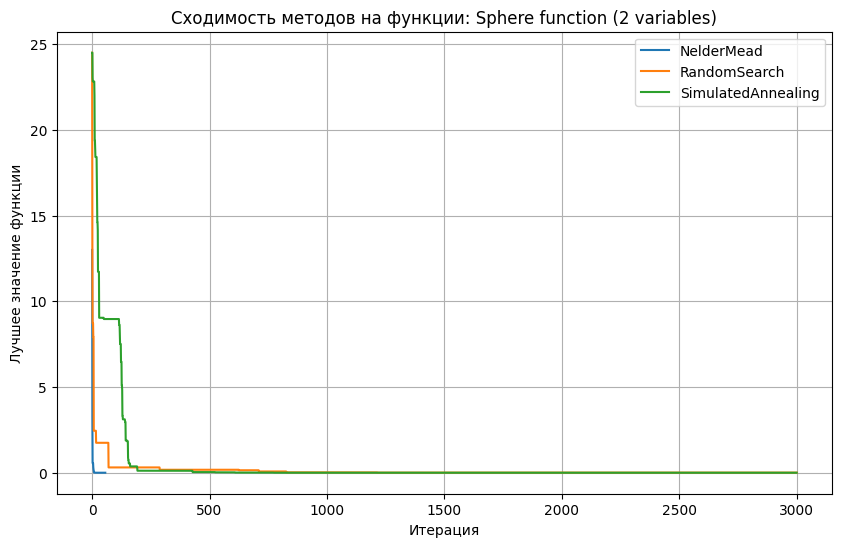

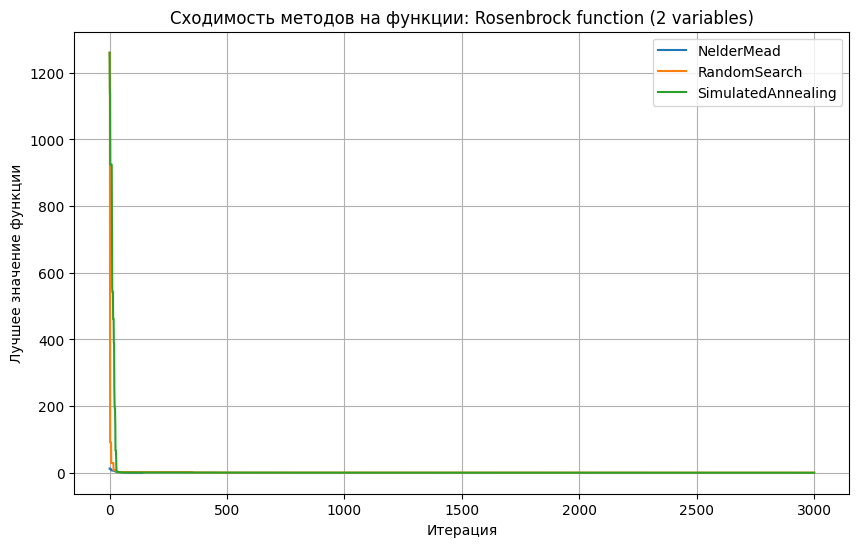

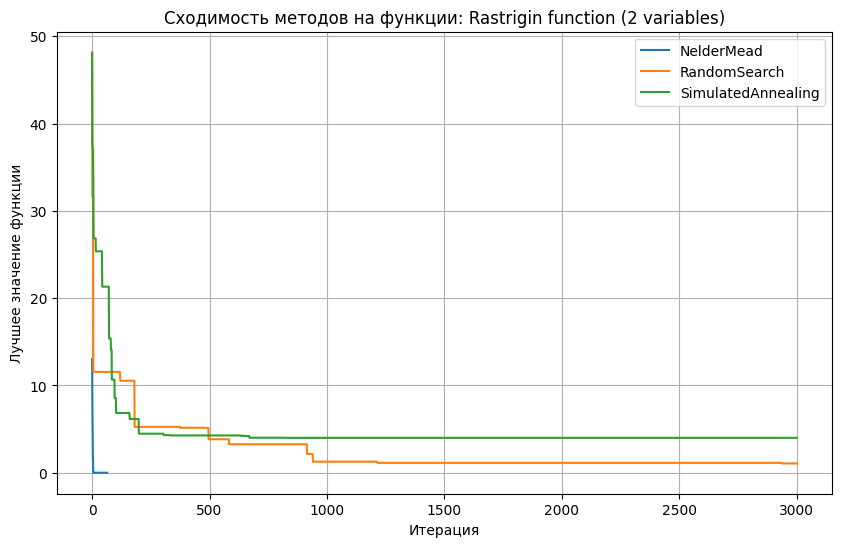

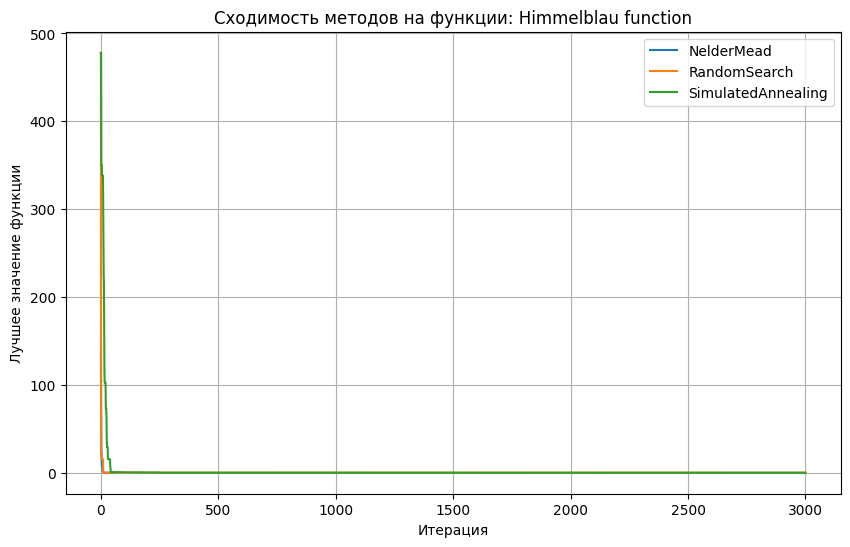

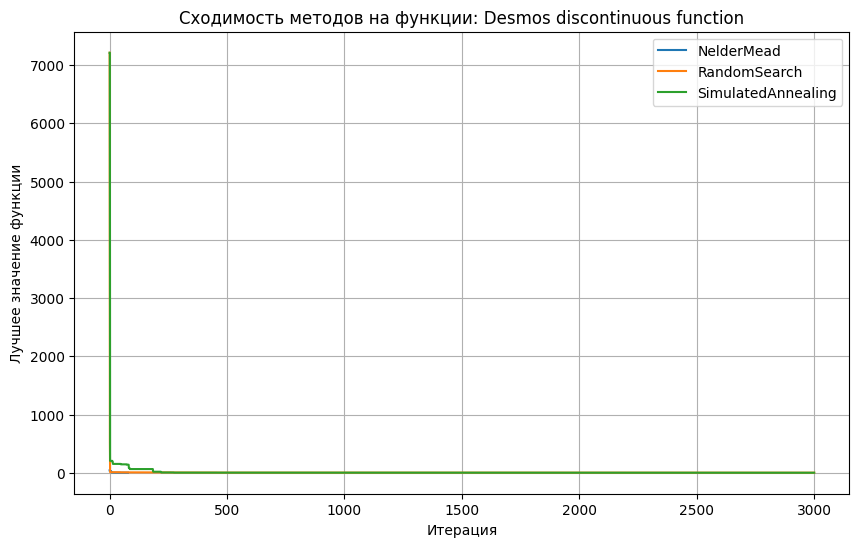

In [25]:
for function_name, histories in all_histories.items():
    plt.figure(figsize=(10, 6))

    for method_name, values in histories.items():
        plt.plot(values, label=method_name)

    plt.xlabel("Итерация")
    plt.ylabel("Лучшее значение функции")
    plt.title(f"Сходимость методов на функции: {function_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

## График вызовов функции

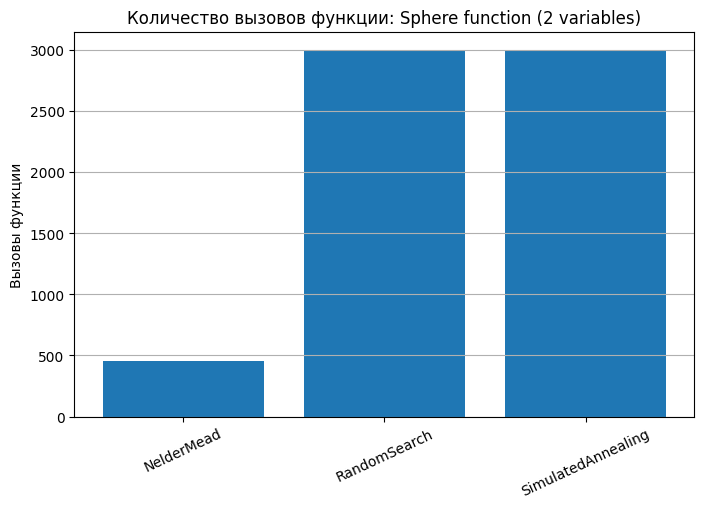

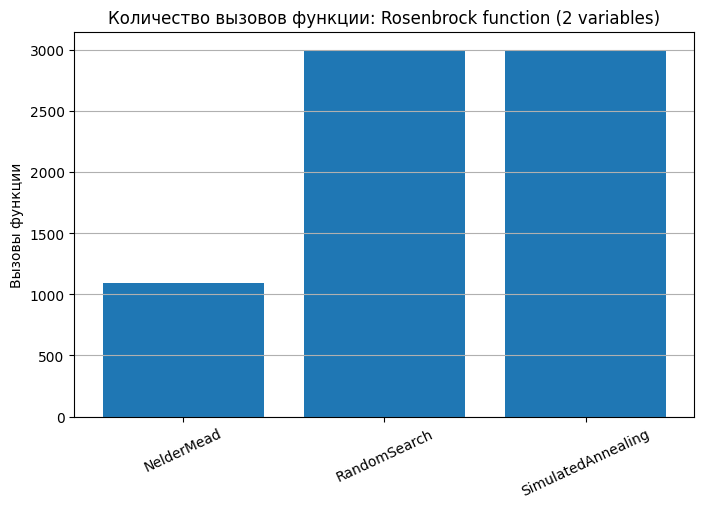

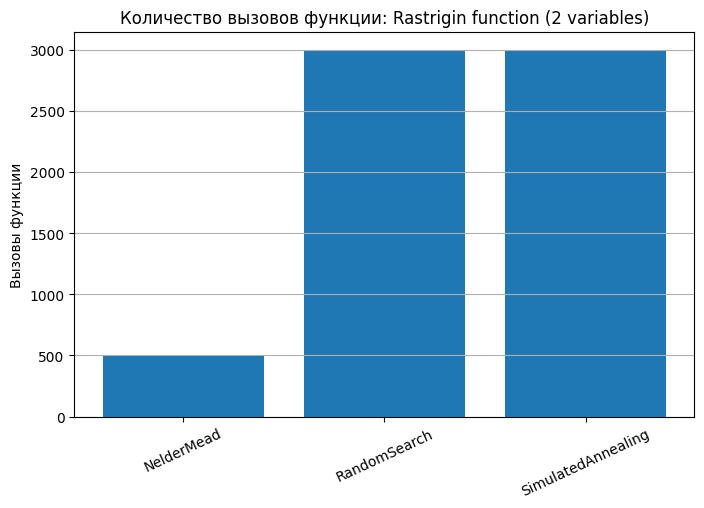

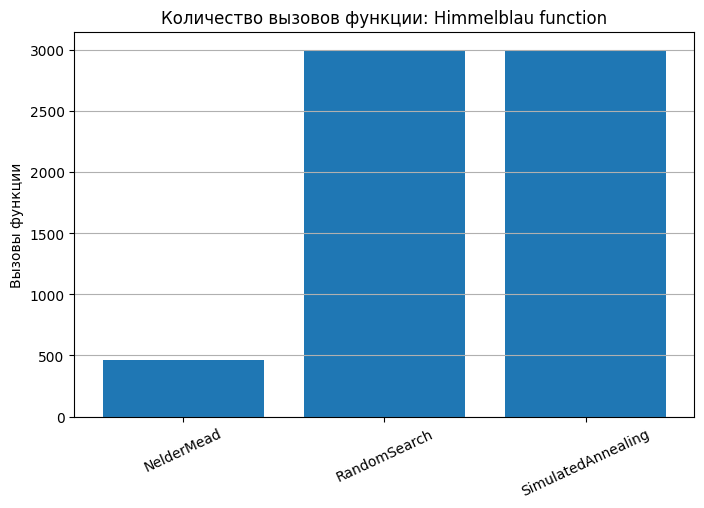

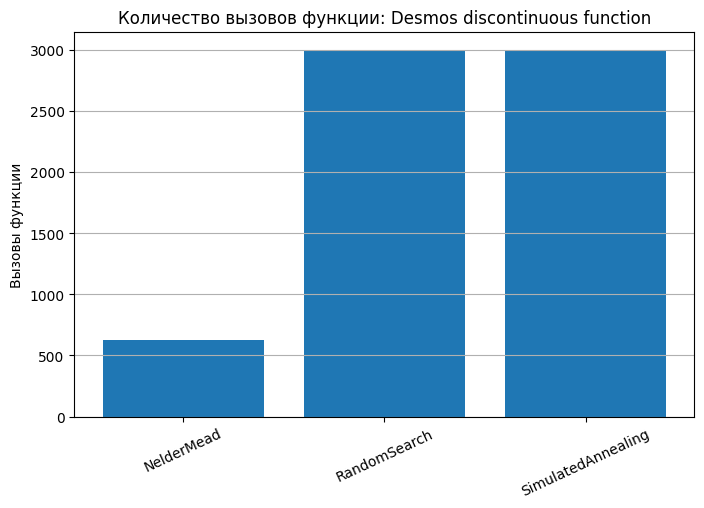

In [26]:
for function_name in df["Функция"].unique():
    part = df[df["Функция"] == function_name]

    plt.figure(figsize=(8, 5))
    plt.bar(part["Метод"], part["Вызовы функции"])

    plt.title(f"Количество вызовов функции: {function_name}")
    plt.ylabel("Вызовы функции")
    plt.xticks(rotation=25)
    plt.grid(True, axis="y")
    plt.show()

## График времени

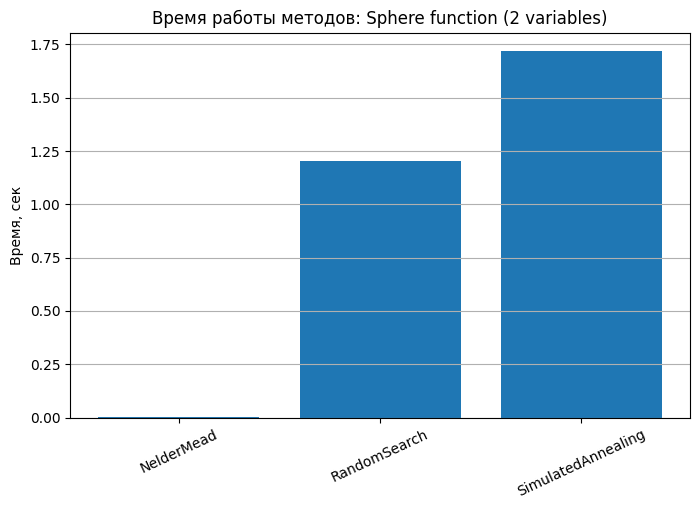

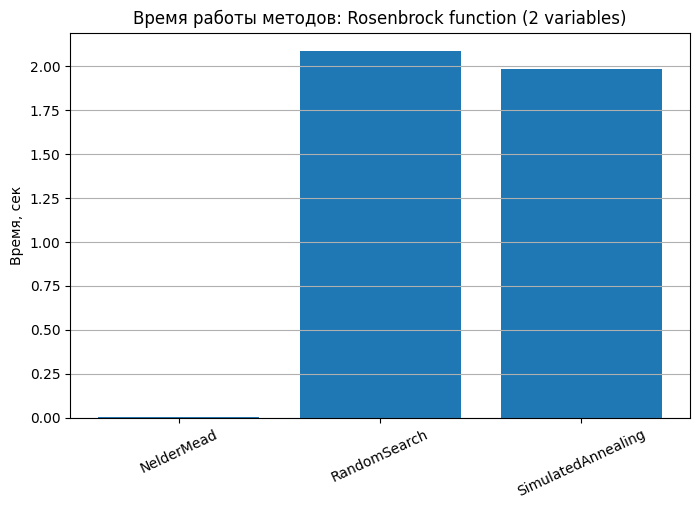

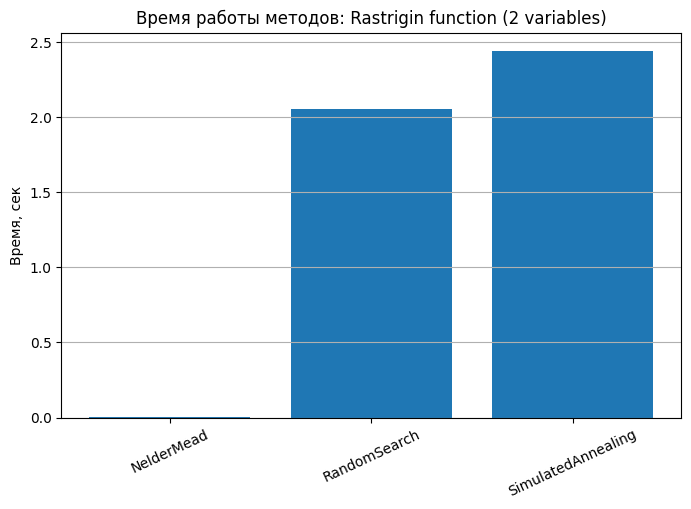

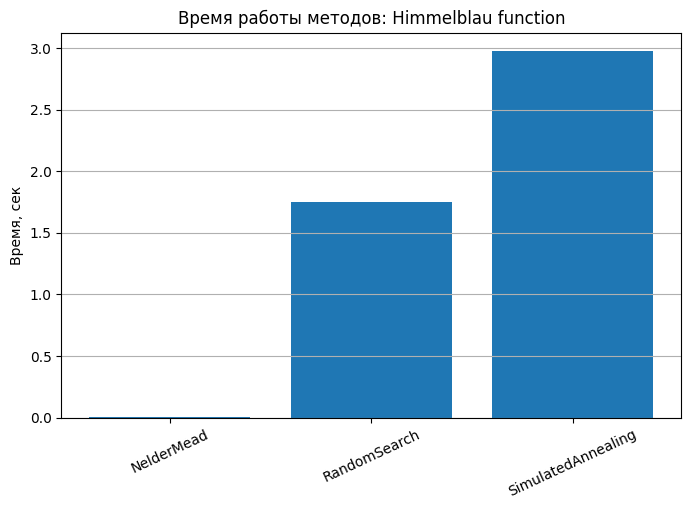

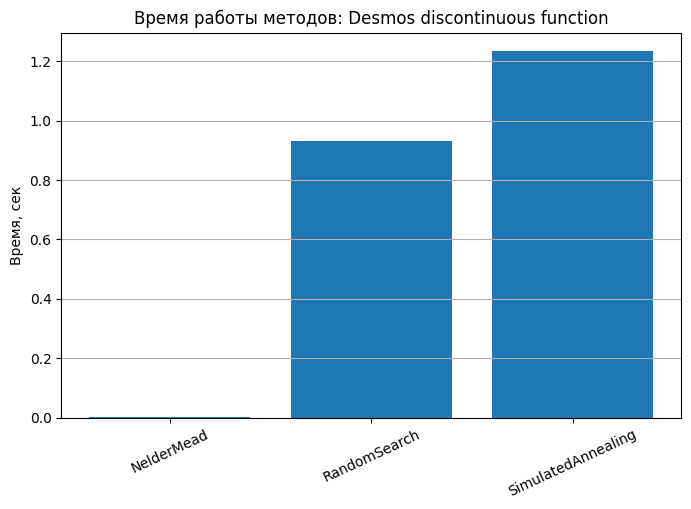

In [27]:
for function_name in df["Функция"].unique():
    part = df[df["Функция"] == function_name]

    plt.figure(figsize=(8, 5))
    plt.bar(part["Метод"], part["Время (сек)"])

    plt.title(f"Время работы методов: {function_name}")
    plt.ylabel("Время, сек")
    plt.xticks(rotation=25)
    plt.grid(True, axis="y")
    plt.show()